In [9]:
from pathlib import Path
from dataclasses import dataclass

import ROOT
ROOT.gErrorIgnoreLevel = ROOT.kWarning 
ROOT.gErrorIgnoreLevel = ROOT.kError
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import ScalarFormatter
import mplhep
mplhep.style.use("CMS")

from utils.plotting import save_fig, hist_to_numpy

In [10]:
%config InlineBackend.figure_format = 'retina'

In [11]:
@dataclass
class Sel:
    name: str
    color: str = None
    label: str = None
    bin_centers: any = None
    bin_widths: any = None
    effi: any = None
    note: str = None

def extract_tefficiency(teff):
    hist = teff.GetTotalHistogram()
    n_bins = hist.GetNbinsX()
    data = [
        (
            hist.GetBinCenter(i),
            hist.GetBinWidth(i),
            teff.GetEfficiency(i),
            teff.GetEfficiencyErrorLow(i),
            teff.GetEfficiencyErrorUp(i)
        )
        for i in range(1, n_bins + 1)
    ]
    bin_centers, bin_widths, effs, err_low, err_up = map(np.array, zip(*data))
    valid = ~np.isnan(effs) & ~np.isnan(err_low) & ~np.isnan(err_up) & (effs > 0)
    return bin_centers[valid], bin_widths[valid], effs[valid], err_low[valid], err_up[valid]

class SelectionExtractor:
    def __init__(self, file: Path):
        self.file = file
        self.tfile = ROOT.TFile.Open(str(file))

    def close_file(self):
        self.tfile.Close()

    def get_hist(self, sel: Sel, var: str) -> ROOT.TH1:
        """Get histogram for a selection and variable from ROOT file"""
        hist_name = f"{sel.name}_{var}"
        hist = self.tfile.Get(hist_name)
        if not hist:
            raise ValueError(f"Histogram '{hist_name}' not found in file")
        return hist

    def get_sel_effis_data(self, lep: str, sels: list[Sel], var: str) -> list[Sel]:
        if lep == 'muon': ref_sel = Sel('SL_mu')
        elif lep == 'electron': ref_sel = Sel('SL_e')
        ref_hist = self.get_hist(ref_sel, var)
        for sel in sels:
            hist = self.get_hist(sel, var)
            effi_hist = ROOT.TEfficiency(hist, ref_hist)
            bin_centers, bin_widths, effi, _, _ = extract_tefficiency(effi_hist)
            sel.bin_centers = bin_centers
            sel.bin_widths = bin_widths
            sel.effi = effi
        return sels, ref_sel

In [12]:
def plot_effis_and_ratio(sels, lep, file_path, save_to: Path=None,
    ylabel = "Efficiency", figsize=(12,10), legend_loc='center right',
    show_ratio=False, ratio_ylim=None, ratio_yticks=None, pretrigger_dist=False):

    label_fontsize = 24
    tick_fontsize = 20
    legend_fontsize = 18
    selection_extractor = SelectionExtractor(file_path)

    # Adjust figure layout based on whether ratio plot is shown
    if show_ratio:
        plt.figure(figsize=figsize, facecolor='white') 
        gs = gridspec.GridSpec(2, 1, height_ratios=[3, 1], hspace=0.05)
        ax_eff = plt.subplot(gs[0])
        ax_ratio = plt.subplot(gs[1], sharex=ax_eff)
    else:
        plt.figure(figsize=figsize, facecolor='white') 
        ax_eff = plt.subplot(1, 1, 1)
    
    mplhep.cms.label("Preliminary", data=False, rlabel="13.6 TeV", ax=ax_eff)
    sels, ref_sel = selection_extractor.get_sel_effis_data(lep, sels, 'pt')
    print(f"{ref_sel.name=}")
    for sel in sels:
        ax_eff.errorbar(sel.bin_centers, sel.effi, xerr=sel.bin_widths / 2, fmt='^', color=sel.color, label=sel.label, markersize=4)

    ax_eff.set_ylabel(ylabel, fontsize=label_fontsize)
    ax_eff.set_ylim(0, 1.1)
    ax_eff.set_xlim(0, 200)
    ax_eff.grid(True)
    
    # Only hide x-axis labels if ratio plot is shown
    if show_ratio:
        ax_eff.tick_params(axis='x', labelsize=tick_fontsize, labelbottom=False)
    else:
        ax_eff.tick_params(axis='x', labelsize=tick_fontsize)
        ax_eff.set_xlabel(f"Offline {lep} $p_T$ (GeV)", fontsize=label_fontsize)

    # Pre-trigger distribution ==============================
    if pretrigger_dist:
        pt_hist = selection_extractor.get_hist(ref_sel, 'Uniform4_start10_pt')
        
        n_bins = pt_hist.GetNbinsX()
        bin_edges = np.array([pt_hist.GetBinLowEdge(i + 1) for i in range(n_bins)] + [pt_hist.GetBinLowEdge(n_bins + 1)])
        bin_contents = np.array([pt_hist.GetBinContent(i + 1) for i in range(n_bins)])
        integral = pt_hist.Integral("width")
        bin_contents_norm = bin_contents / integral

        ax_eff_bar = ax_eff.twinx()
        ax_eff_bar.fill_between(bin_edges[:-1], bin_contents_norm, step='post', color='gray', alpha=0.3, label='Pre-trigger distribution')
        
        formatter = ScalarFormatter(useMathText=True)
        formatter.set_scientific(True)
        formatter.set_powerlimits((-2, 2))  # force scientific notation in a wide range
        ax_eff_bar.yaxis.set_major_formatter(formatter)
        
        ax_eff_bar.yaxis.label.set_color('gray')
        ax_eff_bar.set_ylabel("a.u. (normalized)", fontsize=label_fontsize)
        # ymax = np.max(bin_contents_norm)*1.2
        ymax_for_both = 0.022
        ax_eff_bar.set_yticks(np.arange(0, ymax_for_both, 0.005))
        ax_eff_bar.set_ylim(0, ymax_for_both)
        ax_eff_bar.tick_params(axis='y', labelsize=tick_fontsize, colors='gray')
        ax_eff_bar.tick_params(axis='y', which='minor', color='gray', labelcolor='gray')
        ax_eff_bar.yaxis.get_offset_text().set_x(0.1)
        ax_eff_bar.yaxis.get_offset_text().set_horizontalalignment('left')
        ax_eff_bar.yaxis.offsetText.set_position((1, 1.01))

        # Combine and make one legend ===========================
        handles_eff, labels_eff = ax_eff.get_legend_handles_labels()
        handles_bar, labels_bar = ax_eff_bar.get_legend_handles_labels()
        all_legend_handles = handles_eff + handles_bar
        all_legend_labels = labels_eff + labels_bar
        leg_main = ax_eff_bar.legend(all_legend_handles, all_legend_labels, loc=legend_loc, fontsize=legend_fontsize, frameon=True)
    else:    
        # Main Legend ==========================================
        handles_eff, labels_eff = ax_eff.get_legend_handles_labels()
        leg = ax_eff.legend(handles_eff, labels_eff, loc=legend_loc, fontsize=legend_fontsize, frameon=True)

    leg_main.get_frame().set_linewidth(1.5)      # ⬅️ makes the box border thicker
    leg_main.get_frame().set_edgecolor("black")  # ⬅️ makes it darker (you can use any color)

    # Ratio plot (only if show_ratio is True) ===========================================
    if show_ratio:
        new_strategy = next(sel for sel in sels if sel.note == 'new_strategy')
        old_strategy = next(sel for sel in sels if sel.note == 'old_strategy' )
        ratio = np.divide(new_strategy.effi, old_strategy.effi, out=np.full_like(old_strategy.effi, np.nan), where=old_strategy.effi != 0)
        ax_ratio.errorbar(old_strategy.bin_centers, ratio, 
                          fmt='o', color='blue', markersize=5, capsize=2,
                          label="New Trigger Strategy/Past Trigger Strategy")
        ax_ratio.axhline(1.0, color='gray', linestyle='--', linewidth=1)
        ax_ratio.set_xlabel(f"Offline {lep} $p_T$ (GeV)", fontsize=label_fontsize)
        ax_ratio.set_ylabel("Ratio", fontsize=label_fontsize)

        # yticks = np.arange(1.0, 3.01, 0.5)
        if ratio_ylim is not None:
            ax_ratio.set_ylim(ratio_ylim[0], ratio_ylim[1])
        if ratio_yticks is not None:
            ax_ratio.set_yticks(ratio_yticks)
        ax_ratio.grid(True)
        ax_ratio.tick_params(axis='x', labelsize=tick_fontsize)
        ax_ratio.tick_params(axis='y', labelsize=tick_fontsize)
        leg_ratio = ax_ratio.legend(loc="center right", fontsize=legend_fontsize, frameon=True)

        leg_ratio.get_frame().set_linewidth(1.5)      # ⬅️ makes the box border thicker
        leg_ratio.get_frame().set_edgecolor("black")  # ⬅️ makes

    plt.tight_layout()
    if save_to: save_fig(plt, save_to)
    plt.show()
    selection_extractor.close_file()

## L1_Effis_New

In [ ]:
# workdir = Path('/eos/user/a/anunezde/Z_OUTPUT_eos/Triggers_New/L1_Effis_New')
# file_path = workdir / 'results' / 'bbWW_sl.root'

# l1_muon_sels = [
#     Sel('SL_mu_L1_SingleMu22', 'black', 'L1_SingleMu_22', note='old_strategy'),
#     # Sel('SL_mu_L1_All', 'red', 'OR of existing triggers', note='existing_all'),
#     Sel('SL_mu_L1_Mu12_HTT150er', 'green', 'L1_Mu12_HTT150er'),
#     Sel('SL_mu_L1_Mu12_HTT150er_OR_All', 'blue', 'L1_Mu12_HTT150er OR-ed with \ncomplementary triggers', note='new_strategy'),
#     Sel('SL_mu_L1_Mu14_HTT150er', 'orange', 'L1_Mu14_HTT150er'),
#     Sel('SL_mu_L1_Mu14_HTT150er_OR_All', 'violet', 'L1_Mu14_HTT150er OR-ed with \ncomplementary triggers'),
# ]
# l1_electron_sels = [
#     Sel('SL_e_L1_SingleIsoEG30er2p5', 'black', 'L1_SingleIsoEG30er2p5', note='old_strategy'),
#     # Sel('SL_e_L1_All', 'red', 'OR of existing triggers', note='existing_all'),
#     Sel('SL_e_L1_LooseIsoEG14er2p5_HTT200er', 'green', 'L1_LooseIsoEG14er2p5_HTT200er'),
#     Sel('SL_e_L1_LooseIsoEG14er2p5_HTT200er_OR_All', 'blue', 'L1_LooseIsoEG14er2p5_HTT200er OR-ed with \ncomplementary triggers', note='new_strategy'),
#     Sel('SL_e_L1_LooseIsoEG16er2p5_HTT200er', 'orange', 'L1_LooseIsoEG16er2p5_HTT200er'),
#     Sel('SL_e_L1_LooseIsoEG16er2p5_HTT200er_OR_All', 'violet', 'L1_LooseIsoEG16er2p5_HTT200er OR-ed with \ncomplementary triggers'),
# ]
# ratio_yticks=np.array([1,3,5,7])
# figsize=(10,10)
# plot_effis_and_ratio(l1_muon_sels, 'muon', file_path, workdir / 'L1_SL_mu_effi_pt.pdf', 
#     ylabel='L1 Efficiency', figsize=figsize, legend_loc='lower right',
#     show_ratio=True, ratio_ylim=[0,8], ratio_yticks=ratio_yticks,
#     pretrigger_dist=True)
# plot_effis_and_ratio(l1_electron_sels, 'electron', file_path, workdir / 'L1_SL_e_effi_pt.pdf', 
#     ylabel='L1 Efficiency', figsize=figsize, legend_loc='lower right',
#     show_ratio=True, ratio_ylim=[0,8], ratio_yticks=ratio_yticks,
#     pretrigger_dist=True)

ref_sel.name='SL_mu'


/tmp/anunezde/ipykernel_1487446/23418145.py:107: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Figure saved to /eos/user/a/anunezde/Z_OUTPUT_eos/Triggers_New/L1_Effis_New/L1_SL_mu_effi_pt.pdf


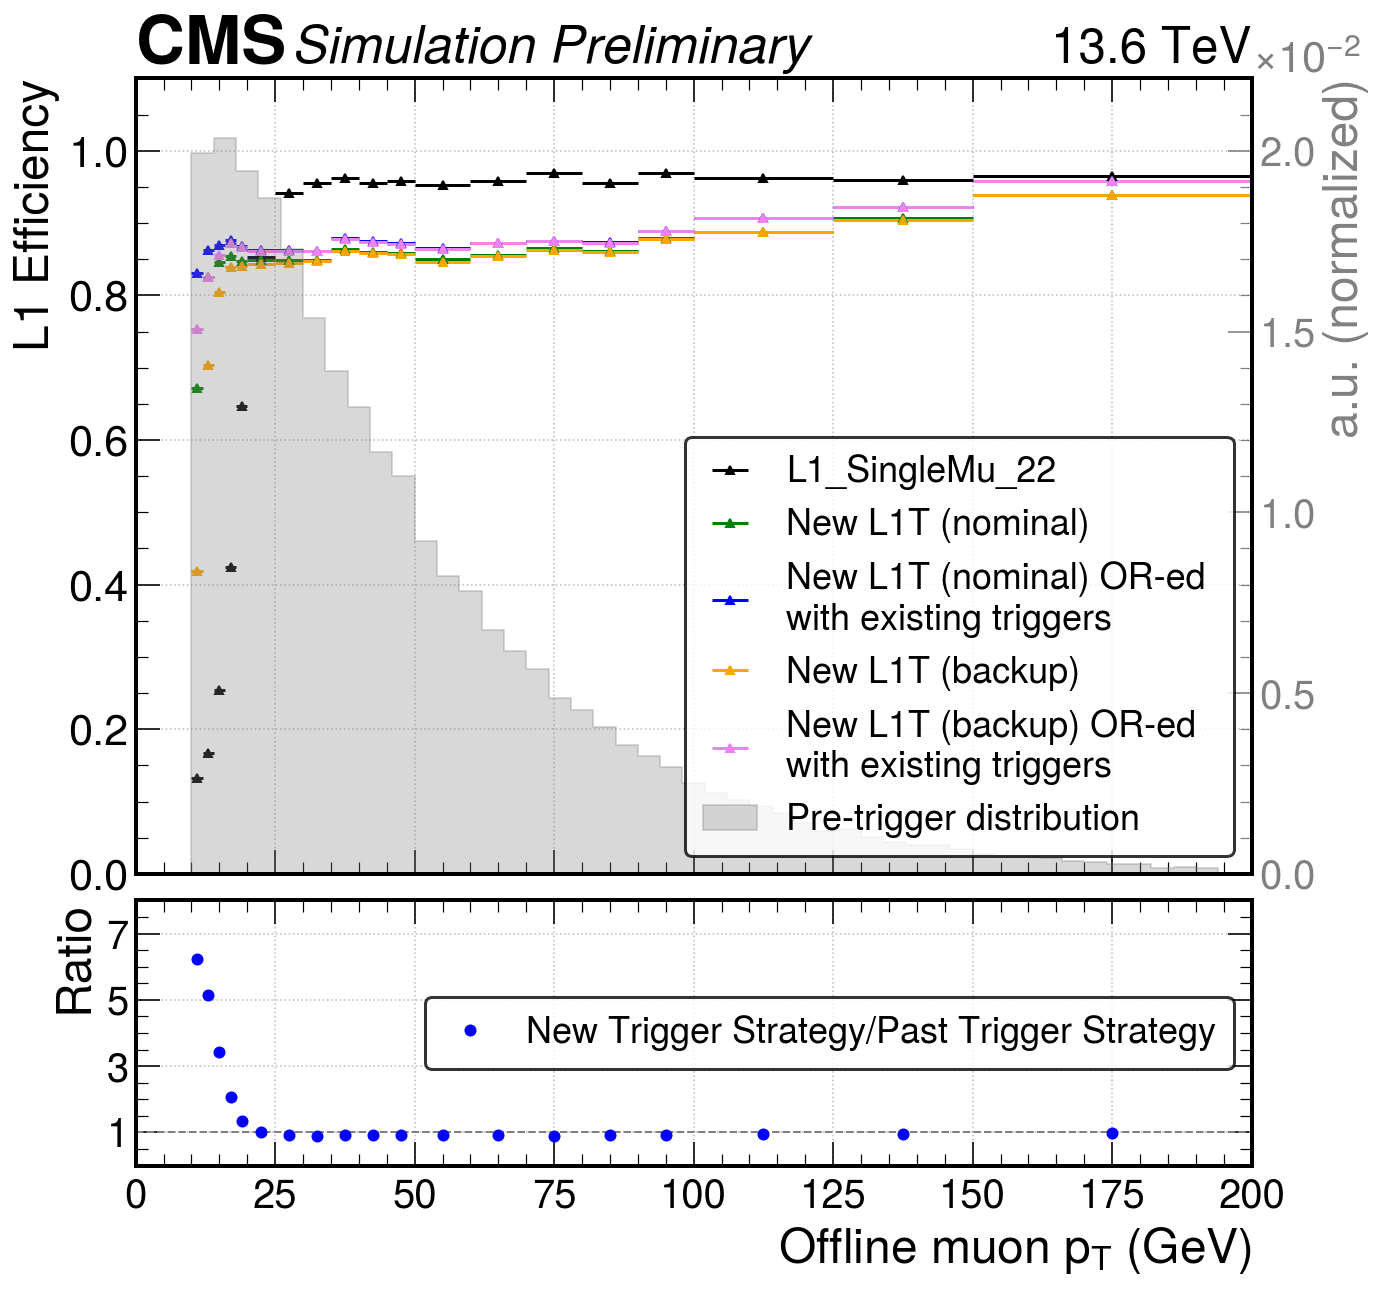

ref_sel.name='SL_e'


/tmp/anunezde/ipykernel_1487446/23418145.py:107: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Figure saved to /eos/user/a/anunezde/Z_OUTPUT_eos/Triggers_New/L1_Effis_New/L1_SL_e_effi_pt.pdf


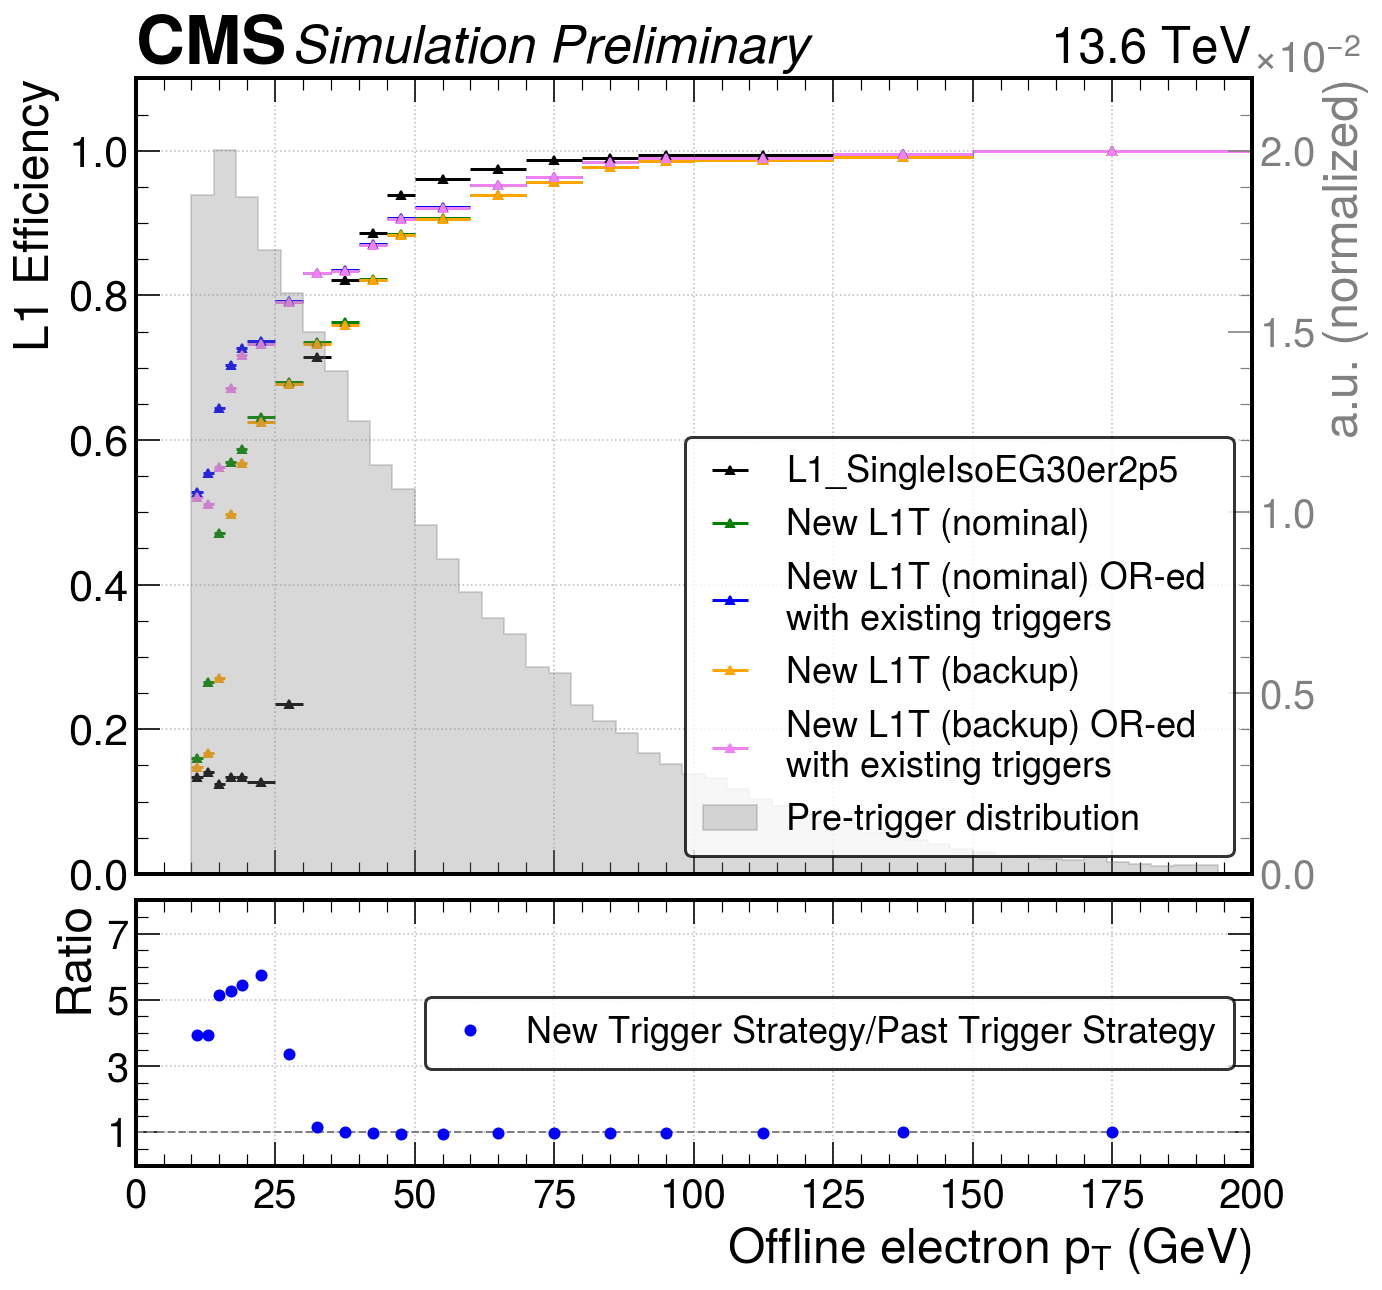

In [14]:
workdir = Path('/eos/user/a/anunezde/Z_OUTPUT_eos/Triggers_New/L1_Effis_New')
file_path = workdir / 'results' / 'bbWW_sl.root'

l1_muon_sels = [
    Sel('SL_mu_L1_SingleMu22', 'black', 'L1_SingleMu_22', note='old_strategy'),
    # Sel('SL_mu_L1_All', 'red', 'OR of existing triggers', note='existing_all'),
    Sel('SL_mu_L1_Mu12_HTT150er', 'green', 'New L1T (nominal)'),
    Sel('SL_mu_L1_Mu12_HTT150er_OR_All', 'blue', 'New L1T (nominal) OR-ed \nwith existing triggers', note='new_strategy'),
    Sel('SL_mu_L1_Mu14_HTT150er', 'orange', 'New L1T (backup)'),
    Sel('SL_mu_L1_Mu14_HTT150er_OR_All', 'violet', 'New L1T (backup) OR-ed \nwith existing triggers'),
]
l1_electron_sels = [
    Sel('SL_e_L1_SingleIsoEG30er2p5', 'black', 'L1_SingleIsoEG30er2p5', note='old_strategy'),
    # Sel('SL_e_L1_All', 'red', 'OR of existing triggers', note='existing_all'),
    Sel('SL_e_L1_LooseIsoEG14er2p5_HTT200er', 'green', 'New L1T (nominal)'),
    Sel('SL_e_L1_LooseIsoEG14er2p5_HTT200er_OR_All', 'blue', 'New L1T (nominal) OR-ed \nwith existing triggers', note='new_strategy'),
    Sel('SL_e_L1_LooseIsoEG16er2p5_HTT200er', 'orange', 'New L1T (backup)'),
    Sel('SL_e_L1_LooseIsoEG16er2p5_HTT200er_OR_All', 'violet', 'New L1T (backup) OR-ed \nwith existing triggers'),
]
ratio_yticks=np.array([1,3,5,7])
figsize=(10,10)
plot_effis_and_ratio(l1_muon_sels, 'muon', file_path, workdir / 'L1_SL_mu_effi_pt.pdf', 
    ylabel='L1 Efficiency', figsize=figsize, legend_loc='lower right',
    show_ratio=True, ratio_ylim=[0,8], ratio_yticks=ratio_yticks,
    pretrigger_dist=True)
plot_effis_and_ratio(l1_electron_sels, 'electron', file_path, workdir / 'L1_SL_e_effi_pt.pdf', 
    ylabel='L1 Efficiency', figsize=figsize, legend_loc='lower right',
    show_ratio=True, ratio_ylim=[0,8], ratio_yticks=ratio_yticks,
    pretrigger_dist=True)

## HLT_Effis_New

In [108]:
# workdir = Path('/eos/user/a/anunezde/Z_OUTPUT_eos/Triggers_New/HLT_Effis_New')
# file_path = workdir / 'results' / 'bbWW_sl.root'

# Configuration of published figures ==============
# hlt_muon_sels = [
#     # Sel('SL_mu_HLT_IsoMu24', 'green', 'SL_mu_HLT_IsoMu24', note=None),
#     Sel('SL_mu_HLT_All', 'black', 'OR of existing triggers', note='old_strategy'),
#     Sel('SL_mu_HLT_Mu12_IsoVVL_PFHT150_PNetBTag_0p53_OR_All', 'red', 'New trigger OR-ed \nwith existing triggers', note='new_strategy'),
# ]
# hlt_electron_sels = [
#     # Sel('SL_e_HLT_Ele30_WPTight_Gsf', 'green', 'SL_e_HLT_Ele30_WPTight_Gsf', note=None),
#     Sel('SL_e_HLT_All', 'black', 'OR of existing triggers', note='old_strategy'),
#     Sel('SL_e_HLT_Ele14_eta2p5_IsoVVVL_Gsf_HT200_PNetBTag_0p53_OR_All', 'red', 'New trigger OR-ed \nwith existing triggers', note='new_strategy'),
# ]

# ratio_yticks=np.arange(1, 3.5, 0.5)
# plot_effis_and_ratio(hlt_muon_sels, 'muon', file_path, workdir / 'HLT_SL_mu_effi_pt.pdf',
#     ylabel='L1 + HLT Efficiency', show_ratio=True, ratio_ylim=[0.75, 3.25], ratio_yticks=ratio_yticks, 
#     pretrigger_dist=True)
# plot_effis_and_ratio(hlt_electron_sels, 'electron', file_path, workdir / 'HLT_SL_mu_effi_pt.pdf',
#     ylabel='L1 + HLT Efficiency', show_ratio=True, ratio_ylim=[0.75, 3.25], ratio_yticks=ratio_yticks, 
#     pretrigger_dist=True)

ref_sel.name='SL_mu'


/tmp/anunezde/ipykernel_1487446/23418145.py:107: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Figure saved to /eos/user/a/anunezde/Z_OUTPUT_eos/Triggers_New/HLT_Effis_New/HLT_SL_mu_effi_pt.pdf


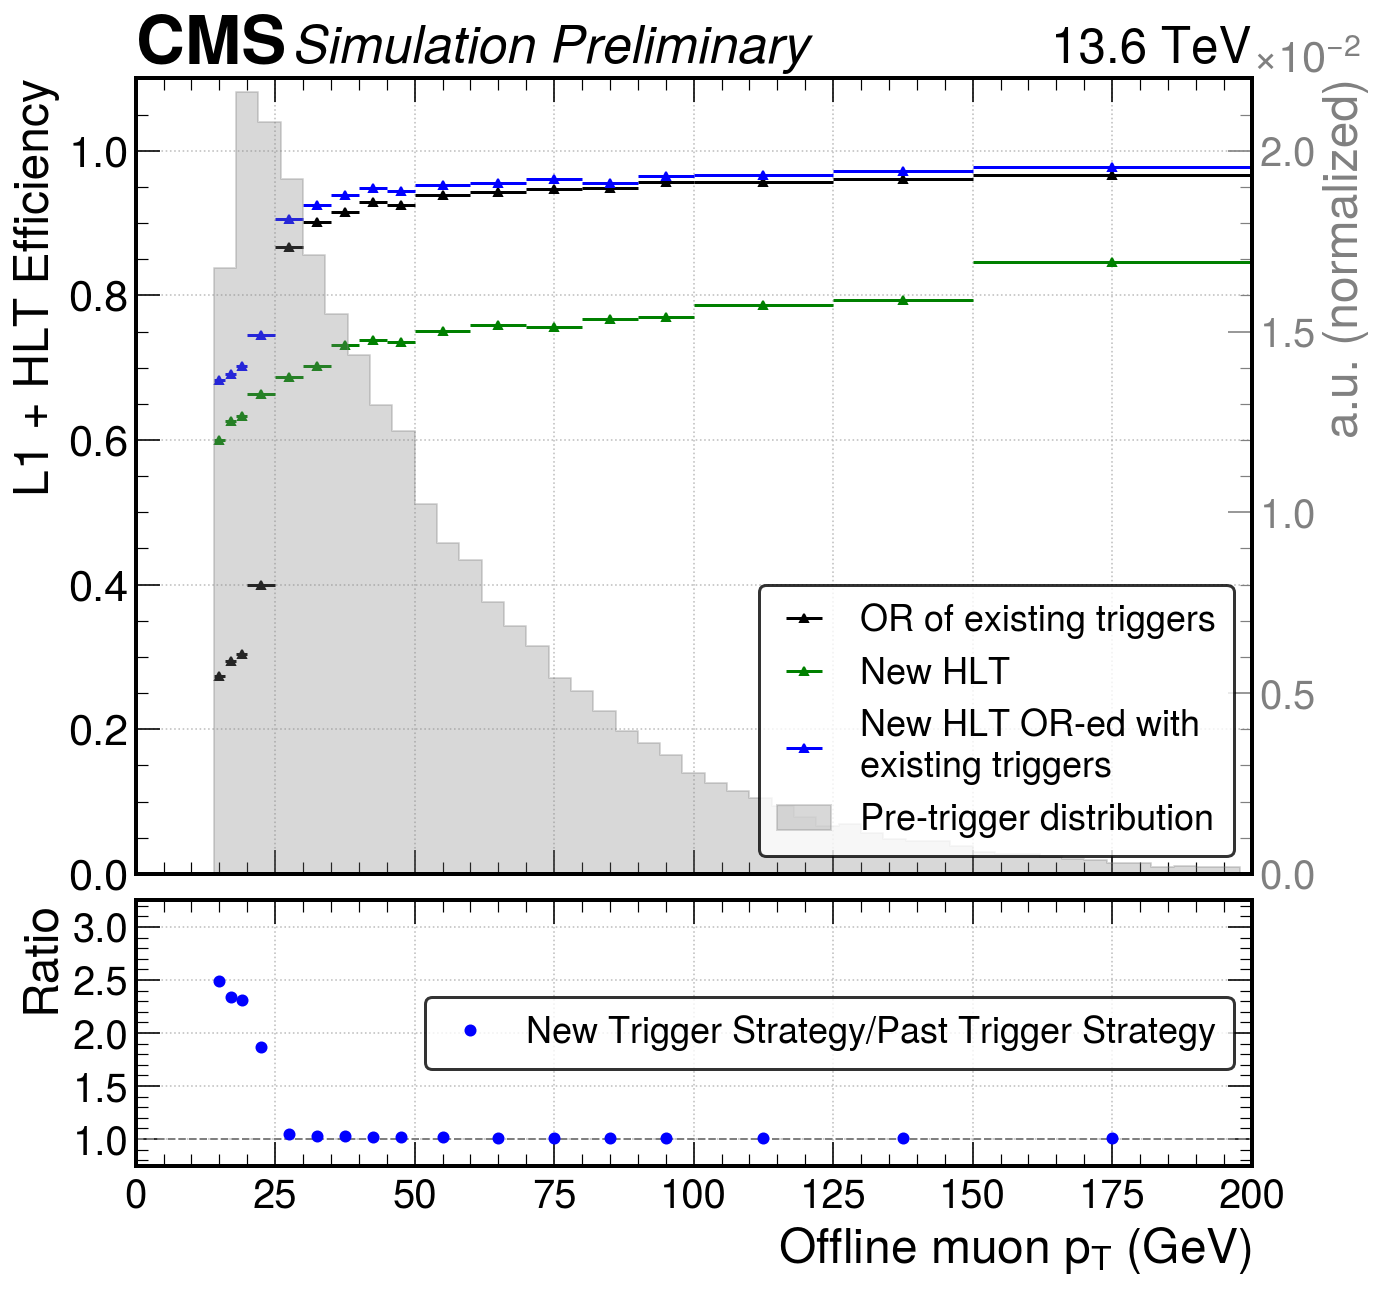

ref_sel.name='SL_e'


/tmp/anunezde/ipykernel_1487446/23418145.py:107: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Figure saved to /eos/user/a/anunezde/Z_OUTPUT_eos/Triggers_New/HLT_Effis_New/HLT_SL_e_effi_pt.pdf


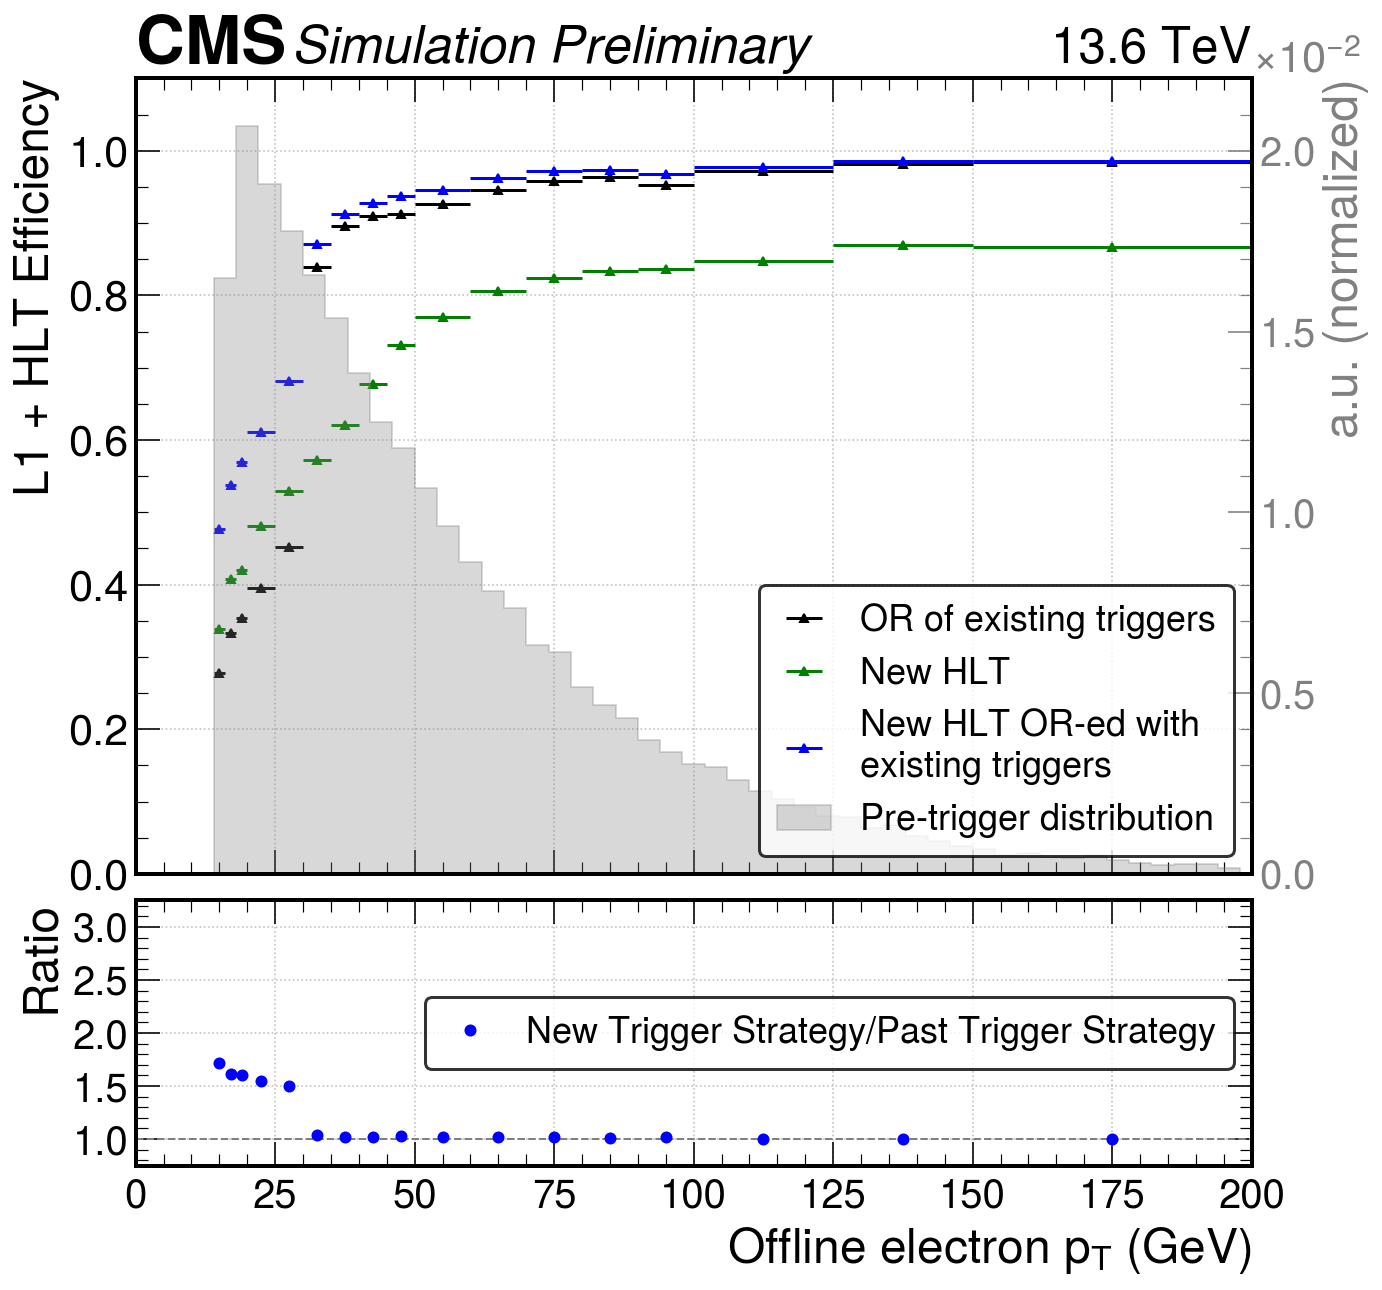

In [17]:
workdir = Path('/eos/user/a/anunezde/Z_OUTPUT_eos/Triggers_New/HLT_Effis_New')
file_path = workdir / 'results' / 'bbWW_sl.root'

hlt_muon_sels = [
    # Sel('SL_mu_HLT_IsoMu24', 'black', 'HLT_IsoMu24', note=None),
    Sel('SL_mu_HLT_All', 'black', 'OR of existing triggers', note='old_strategy'),
    Sel('SL_mu_HLT_Mu12_IsoVVL_PFHT150_PNetBTag_0p53', 'green', 'New HLT'),
    Sel('SL_mu_HLT_Mu12_IsoVVL_PFHT150_PNetBTag_0p53_OR_All', 'blue', 'New HLT OR-ed with \nexisting triggers', note='new_strategy'),
]
hlt_electron_sels = [
    # Sel('SL_e_HLT_Ele30_WPTight_Gsf', 'black', 'Ele30_WPTight_Gsf', note=None),
    Sel('SL_e_HLT_All', 'black', 'OR of existing triggers', note='old_strategy'),
    Sel('SL_e_HLT_Ele14_eta2p5_IsoVVVL_Gsf_HT200_PNetBTag_0p53', 'green', 'New HLT'),
    Sel('SL_e_HLT_Ele14_eta2p5_IsoVVVL_Gsf_HT200_PNetBTag_0p53_OR_All', 'blue', 'New HLT OR-ed with \nexisting triggers', note='new_strategy'),
]

ratio_yticks=np.arange(1, 3.5, 0.5)
figsize=(10,10)
plot_effis_and_ratio(hlt_muon_sels, 'muon', file_path, workdir / 'HLT_SL_mu_effi_pt.pdf',
    ylabel='L1 + HLT Efficiency', figsize=figsize, legend_loc='lower right',
    show_ratio=True, ratio_ylim=[0.75, 3.25], ratio_yticks=ratio_yticks, 
    pretrigger_dist=True)
plot_effis_and_ratio(hlt_electron_sels, 'electron', file_path, workdir / 'HLT_SL_e_effi_pt.pdf',
    ylabel='L1 + HLT Efficiency', figsize=figsize, legend_loc='lower right',
    show_ratio=True, ratio_ylim=[0.75, 3.25], ratio_yticks=ratio_yticks, 
    pretrigger_dist=True)